### 1) Load & quick checks

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/online_retail_clean_final.csv")

print("rows, cols:",df.shape)
display(df.head())
display(df.info())

rows, cols: (536754, 10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsReturn,Revenue
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536754 entries, 0 to 536753
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536754 non-null  object 
 1   StockCode    536754 non-null  object 
 2   Description  536754 non-null  object 
 3   Quantity     536754 non-null  int64  
 4   InvoiceDate  536754 non-null  object 
 5   UnitPrice    536754 non-null  float64
 6   CustomerID   405029 non-null  float64
 7   Country      536754 non-null  object 
 8   IsReturn     536754 non-null  bool   
 9   Revenue      536754 non-null  float64
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 37.4+ MB


None

### 2) Data quality & summary stats

In [2]:
# missing values
df.isna().sum()

# basic stats
df.describe(include='all')

# uniq counts of key fields
print("unique customers:", df['CustomerID'].nunique())
print("unique products:", df['StockCode'].nunique())
print("date range:", df['InvoiceDate'].min(), df['InvoiceDate'].max())

unique customers: 4362
unique products: 3933
date range: 2010-12-01 08:26:00 2011-12-09 12:50:00


### 3) Create derived fields / metrics (do this early)

In [3]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Date'] = df['InvoiceDate'].dt.date
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Year'] = df['InvoiceDate'].dt.year
df['Week'] = df['InvoiceDate'].dt.isocalendar().week
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['IsSale'] = df['Quantity'] > 0

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsReturn,Revenue,Date,YearMonth,Year,Week,IsSale
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30,2010-12-01,2010-12,2010,48,True
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010-12-01,2010-12,2010,48,True
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00,2010-12-01,2010-12,2010,48,True
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010-12-01,2010-12,2010,48,True
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010-12-01,2010-12,2010,48,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536749,581587,22613,pack of 20 spaceboy napkins,12,2011-12-09 12:50:00,0.85,12680.0,France,False,10.20,2011-12-09,2011-12,2011,49,True
536750,581587,22899,children's apron dolly girl,6,2011-12-09 12:50:00,2.10,12680.0,France,False,12.60,2011-12-09,2011-12,2011,49,True
536751,581587,23254,childrens cutlery dolly girl,4,2011-12-09 12:50:00,4.15,12680.0,France,False,16.60,2011-12-09,2011-12,2011,49,True
536752,581587,23255,childrens cutlery circus parade,4,2011-12-09 12:50:00,4.15,12680.0,France,False,16.60,2011-12-09,2011-12,2011,49,True


### 4) Time-series (Sales) analysis — start here after derived fields

In [4]:
monthly_rev = (df[df['IsSale']].groupby('YearMonth')['Revenue'].sum().sort_index())
daily_rev = (df[df['IsSale']].groupby('Date')['Revenue'].sum())
weekday_rev = (df[df['IsSale']].assign(Weekday=df['InvoiceDate'].dt.day_name())
               .groupby('Weekday')['Revenue'].sum().reindex(
                   ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']))

display(monthly_rev)
display(daily_rev)
display(weekday_rev)

YearMonth
2010-12     792152.240
2011-01     672192.410
2011-02     509167.870
2011-03     692235.700
2011-04     516739.791
2011-05     741711.740
2011-06     739426.880
2011-07     689947.741
2011-08     737067.220
2011-09    1031400.361
2011-10    1107419.540
2011-11    1458895.530
2011-12     615701.600
Freq: M, Name: Revenue, dtype: float64

Date
2010-12-01     57676.33
2010-12-02     47715.38
2010-12-03     44833.98
2010-12-05     31318.99
2010-12-06     51973.43
                ...    
2011-12-05     80182.35
2011-12-06     55411.69
2011-12-07     72922.70
2011-12-08     77694.64
2011-12-09    198114.26
Name: Revenue, Length: 305, dtype: float64

Weekday
Monday       1687917.290
Tuesday      2102766.301
Wednesday    1787722.360
Thursday     2137585.270
Friday       1782219.071
Saturday             NaN
Sunday        805848.331
Name: Revenue, dtype: float64

### 5) Product analysis

In [5]:
top_by_revenue = df[df['IsSale']].groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(20)
top_by_qty = df[df['IsSale']].groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)

# concentration (Pareto)
sku_rev = df[df['IsSale']].groupby('Description')['Revenue'].sum().sort_values(ascending=False)
sku_rev.cumsum() / sku_rev.sum()

Description
regency cakestand 3 tier              0.016934
paper craft , little birdie           0.033283
white hanging heart t-light holder    0.043599
party bunting                         0.053256
jumbo bag red retrospot               0.062411
                                        ...   
pink crystal guitar phone charm       1.000000
vintage blue tinsel reel              1.000000
set 12 colouring pencils doiley       1.000000
hen house w chick in nest             1.000000
pads to match all cushions            1.000000
Name: Revenue, Length: 4012, dtype: float64

SKUs to reach 80% revenue: 849 out of 4012
Percent of SKUs: 21.161515453639083


,Description,Revenue,CumulativeRevenue,CumulativeShare
0,regency cakestand 3 tier,174484.74,174484.74,0.016934
1,"paper craft , little birdie",168469.60,342954.34,0.033283
2,white hanging heart t-light holder,106292.77,449247.11,0.043599
3,party bunting,99504.33,548751.44,0.053256
4,jumbo bag red retrospot,94340.05,643091.49,0.062411
5,medium ceramic top storage jar,81700.92,724792.41,0.070340
6,rabbit night light,66964.99,791757.40,0.076839
7,paper chain kit 50's christmas,64952.29,856709.69,0.083143
8,assorted colour bird ornament,59094.93,915804.62,0.088878
9,chilli lights,54117.76,969922.38,0.094130


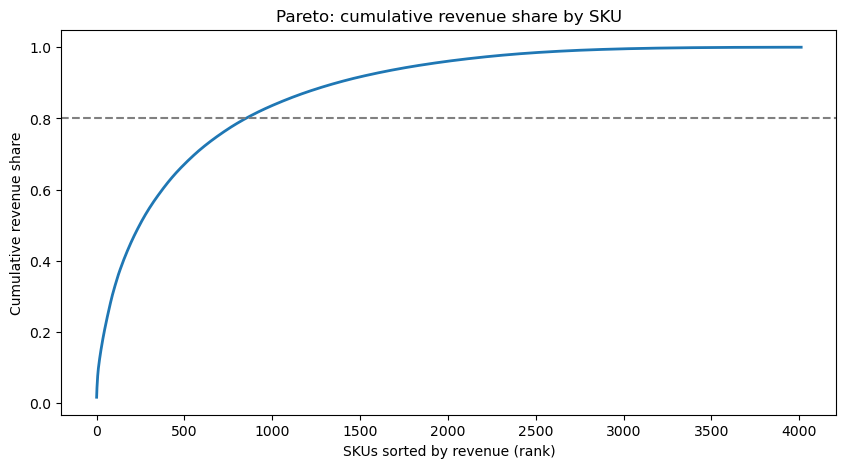

In [6]:
# 1) Dataframe with revenue and cumulative share
sku = sku_rev.reset_index().rename(columns={'Revenue':'Revenue'})
sku['CumulativeRevenue'] = sku['Revenue'].cumsum()
sku['CumulativeShare'] = sku['CumulativeRevenue'] / sku['Revenue'].sum()

# 2) How many SKUs make 80% of revenue?
n_80 = (sku['CumulativeShare'] <= 0.80).sum()
print("SKUs to reach 80% revenue:", n_80, "out of", len(sku))

# 3) What percent of SKUs are these?
print("Percent of SKUs:", 100 * n_80 / len(sku))

# 4) Top 20 SKUs table
display(sku.head(20))

# 5) Pareto plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(sku['CumulativeShare'].values, linewidth=2)
ax.set_xlabel('SKUs sorted by revenue (rank)')
ax.set_ylabel('Cumulative revenue share')
ax.set_title('Pareto: cumulative revenue share by SKU')
ax.axhline(0.8, color='gray', linestyle='--')  # 80% line
plt.show()

### 6) Customer analysis

In [7]:
orders = df[df['IsSale']].groupby('InvoiceNo').agg({'Revenue':'sum','CustomerID':'first'})
AOV = orders['Revenue'].mean()

cust_rev = df[df['IsSale']].groupby('CustomerID')['Revenue'].sum()
repeat_counts = df[df['IsSale']].groupby('CustomerID')['InvoiceNo'].nunique()
repeat_rate = (repeat_counts > 1).mean()

display(cust_rev)
display(repeat_counts)
display(repeat_rate)

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1437.24
12349.0     1457.55
12350.0      294.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2088.93
18287.0     1837.28
Name: Revenue, Length: 4334, dtype: float64

CustomerID
12346.0     1
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     2
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4334, dtype: int64

0.6527457314259345

### 7) Returns & refund analysis

In [8]:
total_lines = len(df)
return_lines = df[~df['IsSale']].shape[0]
return_rate = return_lines / total_lines

returns_by_product = (df[~df['IsSale']].groupby('Description')['Quantity'].count()
                      .sort_values(ascending=False).head(20))

display(returns_by_product)

Description
regency cakestand 3 tier               181
jam making set with jars                87
set of 3 cake tins pantry design        74
samples                                 61
strawberry ceramic trinket box          55
roses regency teacup and saucer         54
recipe box pantry yellow design         47
wood 2 drawer cabinet white finish      45
lunch bag red retrospot                 44
jumbo bag red retrospot                 44
red retrospot cake stand                42
green regency teacup and saucer         42
white hanging heart t-light holder      42
small glass heart trinket pot           40
set of 3 regency cake tins              37
popcorn holder                          36
pink regency teacup and saucer          35
set of tea coffee sugar tins pantry     35
silver hanging t-light holder           35
set/5 red retrospot lid glass bowls     34
Name: Quantity, dtype: int64

### 8) Cross-cutting analyses / segments

In [9]:
country_rev = df[df['IsSale']].groupby('Country')['Revenue'].sum().sort_values(ascending=False)
display(country_rev)

Country
United Kingdom          8774611.223
Netherlands              283889.340
EIRE                     276404.300
Germany                  205569.890
France                   184768.740
Australia                138171.310
Spain                     55725.110
Switzerland               53087.900
Japan                     37416.370
Belgium                   36927.340
Sweden                    36839.330
Norway                    32454.640
Portugal                  27015.160
Channel Islands           20157.440
Finland                   18344.880
Denmark                   18211.340
Italy                     15820.240
Cyprus                    13254.690
Hong Kong                  9952.990
Singapore                  9120.390
Austria                    8742.680
Israel                     8135.260
Poland                     6974.650
Unspecified                4749.790
Greece                     4425.520
Iceland                    4310.000
USA                        3580.390
Canada              

### 9) Visualizations & export (presentable)

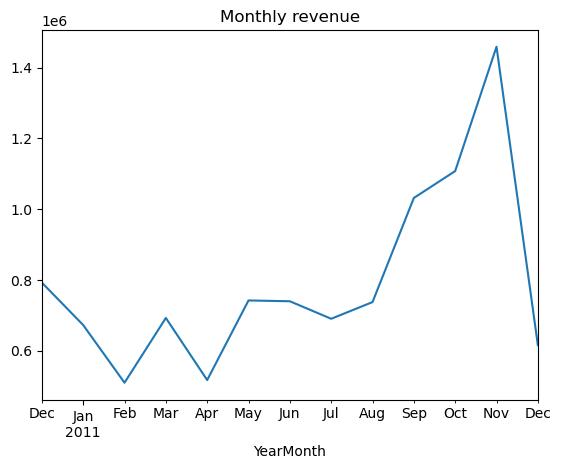

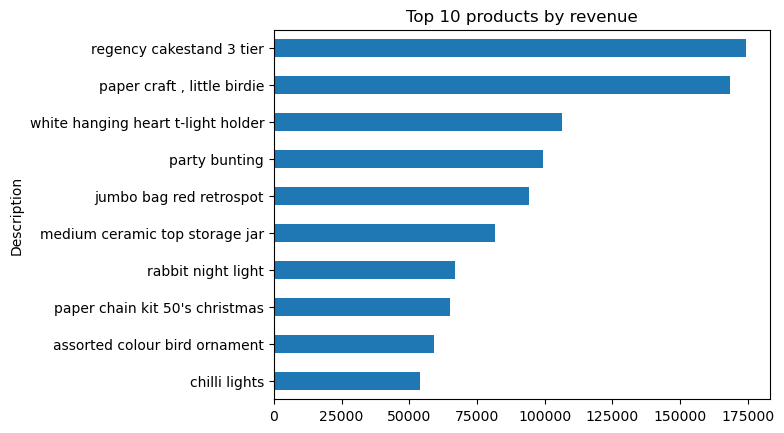

In [10]:
import matplotlib.pyplot as plt
monthly_rev.plot(title="Monthly revenue"); plt.show()
top_by_revenue.head(10).plot(kind='barh', title='Top 10 products by revenue'); plt.gca().invert_yaxis(); plt.show()

In [11]:
monthly_rev.to_csv('../data/processed/monthly_revenue.csv')
top_by_revenue.to_csv('../data/processed/top_products.csv')

### Deepen EDA

#### A. Pareto: exactly how many SKUs make 80% of revenue

In [12]:
# Pareto / SKU concentration
sku_rev = df[df['IsSale']].groupby('Description')['Revenue'].sum().sort_values(ascending=False)
sku = sku_rev.reset_index().rename(columns={0:'Description', 'Revenue':'Revenue'}) if False else sku_rev.reset_index().rename(columns={0:'Revenue'})
sku.columns = ['Description','Revenue']
sku['CumulativeRevenue'] = sku['Revenue'].cumsum()
sku['CumulativeShare'] = sku['CumulativeRevenue'] / sku['Revenue'].sum()

n_80 = (sku['CumulativeShare'] <= 0.80).sum()
pct_80 = 100 * n_80 / len(sku)
print("SKUs to reach 80% revenue:", n_80, "out of", len(sku), f"({pct_80:.2f}%)")

# show top 20
display(sku.head(20))

SKUs to reach 80% revenue: 849 out of 4012 (21.16%)


,Description,Revenue,CumulativeRevenue,CumulativeShare
0,regency cakestand 3 tier,174484.74,174484.74,0.016934
1,"paper craft , little birdie",168469.60,342954.34,0.033283
2,white hanging heart t-light holder,106292.77,449247.11,0.043599
3,party bunting,99504.33,548751.44,0.053256
4,jumbo bag red retrospot,94340.05,643091.49,0.062411
5,medium ceramic top storage jar,81700.92,724792.41,0.070340
6,rabbit night light,66964.99,791757.40,0.076839
7,paper chain kit 50's christmas,64952.29,856709.69,0.083143
8,assorted colour bird ornament,59094.93,915804.62,0.088878
9,chilli lights,54117.76,969922.38,0.094130


In [13]:
sku.to_csv("../data/processed/sku_pareto.csv", index=False)

#### B. Returns analysis (global + by product + by month)

In [14]:
# global return rate (by line)
total_lines = len(df)
return_lines = len(df[~df['IsSale']])
return_rate_lines = return_lines / total_lines
print("Return lines:", return_lines, "/", total_lines, f"({return_rate_lines:.2%})")

# returns by product (top 20)
returns_by_product = (df[~df['IsSale']]
                      .groupby('Description')['Quantity']
                      .count()
                      .sort_values(ascending=False)
                      .head(20))
display(returns_by_product)

# return rate by product = returns / (sales + returns) for those products
prod_sales = df.groupby('Description')['Quantity'].apply(lambda x: (x>0).sum())
prod_returns = df.groupby('Description')['Quantity'].apply(lambda x: (x<0).sum())
prod_return_rate = (prod_returns / (prod_sales + prod_returns)).sort_values(ascending=False).dropna().head(20)
display(prod_return_rate)

# returns by month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
returns_by_month = df[~df['IsSale']].groupby('YearMonth')['Revenue'].sum()
sales_by_month = df[df['IsSale']].groupby('YearMonth')['Revenue'].sum()
returns_ratio_by_month = (returns_by_month / (sales_by_month + 1e-9)).fillna(0)
display(returns_by_month.head(), returns_ratio_by_month.head())

# Save
returns_by_product.to_csv("../data/processed/returns_by_product.csv")
prod_return_rate.to_csv("../data/processed/prod_return_rate.csv")
returns_by_month.to_csv("../data/processed/returns_by_month.csv")

Return lines: 8815 / 536754 (1.64%)


Description
regency cakestand 3 tier               181
jam making set with jars                87
set of 3 cake tins pantry design        74
samples                                 61
strawberry ceramic trinket box          55
roses regency teacup and saucer         54
recipe box pantry yellow design         47
wood 2 drawer cabinet white finish      45
lunch bag red retrospot                 44
jumbo bag red retrospot                 44
red retrospot cake stand                42
green regency teacup and saucer         42
white hanging heart t-light holder      42
small glass heart trinket pot           40
set of 3 regency cake tins              37
popcorn holder                          36
pink regency teacup and saucer          35
set of tea coffee sugar tins pantry     35
silver hanging t-light holder           35
set/5 red retrospot lid glass bowls     34
Name: Quantity, dtype: int64

Description
assorted tutti frutti round box        1.000000
flamingo lights                        1.000000
tea time cake stand in gift box        1.000000
cruk commission                        1.000000
cream sweetheart trays                 1.000000
cream sweetheart shelf + hooks         1.000000
cream sweetheart magazine rack         1.000000
porcelain hanging bell small           1.000000
vintage gold tinsel reel               1.000000
sweetheart key cabinet                 1.000000
blue flying singing canary             1.000000
pink large jeweled photoframe          1.000000
woolly hat sock glove advent string    1.000000
white cherry lights                    1.000000
antique lily fairy lights              1.000000
samples                                0.968254
amazon fee                             0.941176
blue padded soft mobile                0.750000
black cherry lights                    0.666667
pink cherry lights                     0.666667
Name: Quantity, dtype: float

YearMonth
2010-12    -70457.22
2011-01   -124918.03
2011-02    -20028.34
2011-03    -21929.98
2011-04    -33316.91
Freq: M, Name: Revenue, dtype: float64

YearMonth
2010-12   -0.088944
2011-01   -0.185837
2011-02   -0.039335
2011-03   -0.031680
2011-04   -0.064475
Freq: M, Name: Revenue, dtype: float64

#### C. Customer RFM (Recency, Frequency, Monetary) + scoring

In [15]:
import numpy as np

# use snapshot date = last invoice date in data + 1 day (or today)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = (df[df['CustomerID'].notna() & df['IsSale']]
       .groupby('CustomerID')
       .agg({
           'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
           'InvoiceNo': 'nunique',
           'Revenue': 'sum'
       }).rename(columns={'InvoiceDate':'Recency','InvoiceNo':'Frequency','Revenue':'Monetary'}))

# RFM scoring (1-5 each)
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)     # recent = high score
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_Score'] = rfm[['R_score','F_score','M_score']].sum(axis=1)
rfm.head()

# Top segments and counts
display(rfm.groupby('RFM_Score').size().sort_index())
display(rfm.sort_values('RFM_Score', ascending=False).head(10))

# Export
rfm.reset_index().to_csv("../data/processed/rfm_customers.csv", index=False)

RFM_Score
3     179
4     362
5     346
6     423
7     370
8     378
9     331
10    346
11    343
12    324
13    282
14    299
15    351
dtype: int64

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Segment,RFM_Score
CustomerID,,,,,,,,
15298.0,2,12,4799.90,5,5,5,555,15
13263.0,1,34,7428.85,5,5,5,555,15
16592.0,4,16,4113.68,5,5,5,555,15
13230.0,4,14,2806.97,5,5,5,555,15
16558.0,1,20,8338.49,5,5,5,555,15
16549.0,10,10,4154.64,5,5,5,555,15
16525.0,2,26,13027.45,5,5,5,555,15
16523.0,2,21,9418.47,5,5,5,555,15
13266.0,11,12,3834.26,5,5,5,555,15


#### D. Customer KPIs: AOV, repeat rate, top customers

In [16]:
orders = df[df['IsSale']].groupby('InvoiceNo').agg({'Revenue':'sum','CustomerID':'first'})
AOV = orders['Revenue'].mean()
unique_customers = df['CustomerID'].nunique()
repeat_counts = df[df['IsSale']].groupby('CustomerID')['InvoiceNo'].nunique()
repeat_rate = (repeat_counts > 1).mean()

print("AOV:", AOV)
print("Unique customers:", unique_customers)
print("Repeat customer rate:", f"{repeat_rate:.2%}")

top_customers = rfm['Monetary'].sort_values(ascending=False).head(20)
display(top_customers)
top_customers.to_csv("../data/processed/top_customers.csv")

AOV: 520.9068612810272
Unique customers: 4362
Repeat customer rate: 65.27%


CustomerID
14646.0    279138.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    140450.72
12415.0    124564.53
14156.0    117379.63
17511.0     91062.38
12346.0     77183.60
16029.0     72882.09
16684.0     66653.56
13694.0     65039.62
15311.0     60767.90
13089.0     58825.83
17949.0     58030.48
15769.0     56252.72
15061.0     54534.14
14096.0     53258.43
14298.0     51527.30
14088.0     50491.81
Name: Monetary, dtype: float64

#### E. Plots to include in your report (matplotlib)

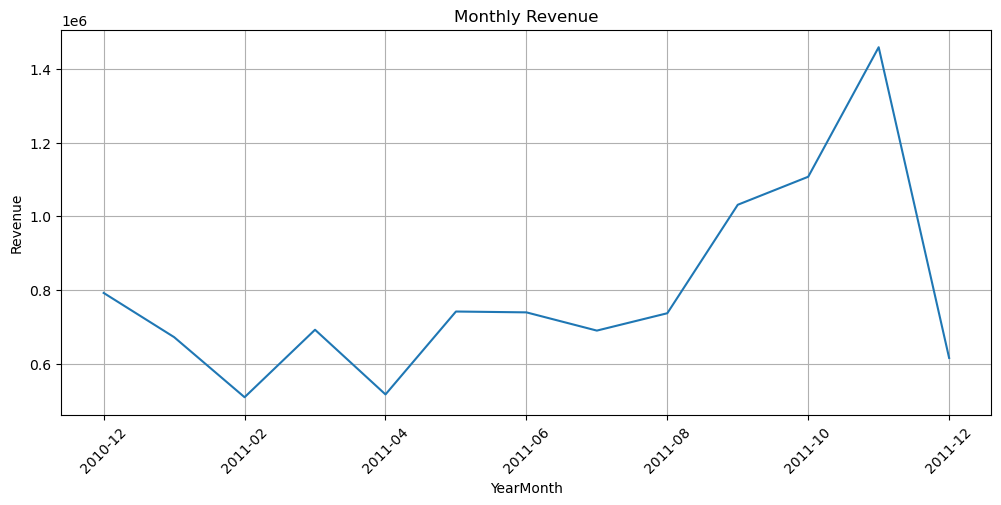

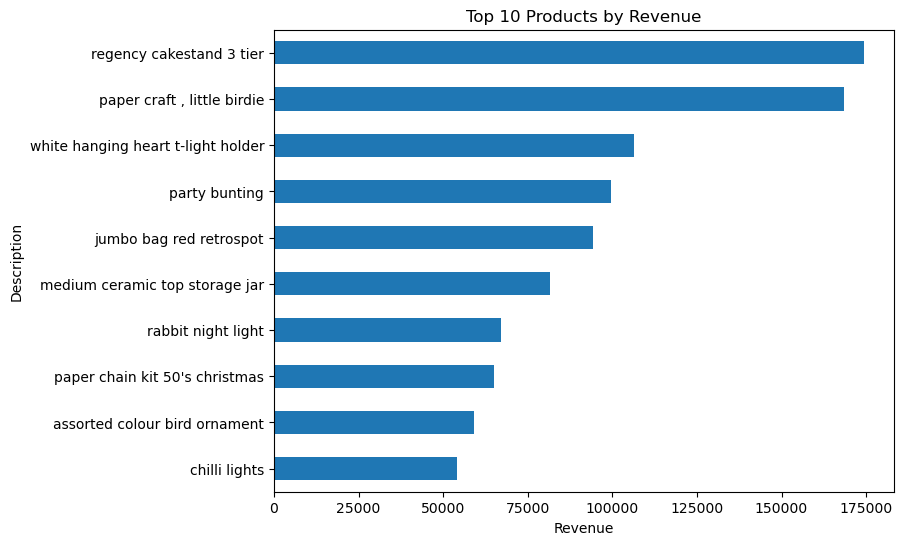

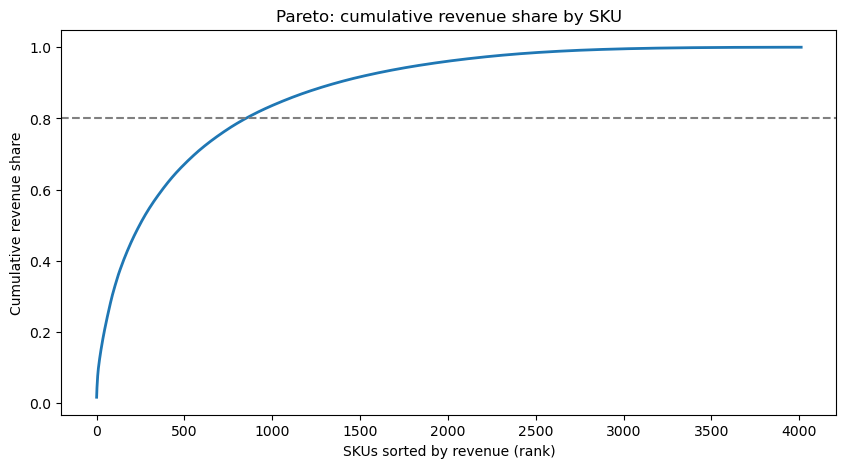

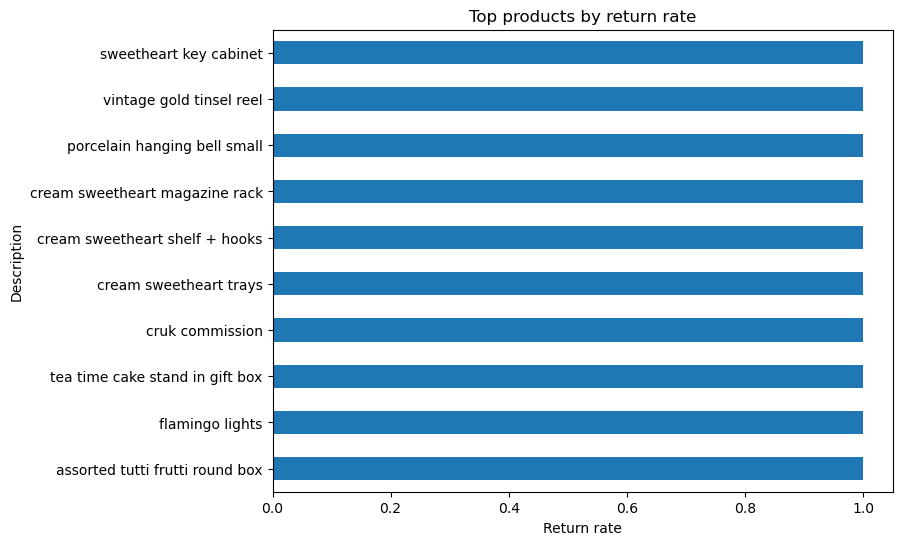

In [17]:
import matplotlib.pyplot as plt

# Monthly revenue plot
monthly_rev = df[df['IsSale']].groupby('YearMonth')['Revenue'].sum().sort_index()
monthly_rev.index = monthly_rev.index.astype(str)
plt.figure(figsize=(12,5)); monthly_rev.plot(); plt.title("Monthly Revenue"); plt.ylabel("Revenue"); plt.xticks(rotation=45); plt.grid(); plt.show()

# Top products bar
top_products = df[df['IsSale']].groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,6)); top_products.sort_values().plot(kind='barh'); plt.title("Top 10 Products by Revenue"); plt.xlabel("Revenue"); plt.show()

# Pareto cumulative plot
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(sku['CumulativeShare'].values, linewidth=2)
ax.set_xlabel('SKUs sorted by revenue (rank)')
ax.set_ylabel('Cumulative revenue share')
ax.set_title('Pareto: cumulative revenue share by SKU')
ax.axhline(0.8, color='gray', linestyle='--')
plt.show()

# Return rate by product (top 10)
plt.figure(figsize=(8,6)); prod_return_rate.head(10).plot(kind='barh'); plt.title("Top products by return rate"); plt.xlabel("Return rate"); plt.show()